# 01. Exploratory Data Analysis (EDA) & Stratified Validation Split
**Amazon ML Challenge 2026 — Business Entity Resolution**

### Objectives
1. **Load all 4 Training TSVs** (`sep="\t"`), verify schema, shapes, dtypes, and null counts.
2. **Inspect Country Distributions** across Train and Test sets, confirming that `France` only appears in Test (open-set country constraint).
3. **Analyze Ground Truth Match-Count Distribution** (0, 1, 2, 3+ matches per S1 entity) and visualize using the project semantic color palette (`design.md`).
4. **Extract 40 Real Matched Pairs** across Source 1 and Source 2/3 (names & addresses side-by-side) to build a hand-crafted noise pattern table.
5. **Create & Lock Stratified Train/Val Split** (`dataset/val_split_ids.txt`) by match-count bucket, ensuring it is never overwritten once created.

In [1]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Ensure working directory is project root
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print(f"Project root working directory: {os.getcwd()}")

# -------------------------------------------------------------
# Color Palette & Style from Documentation/design.md
# -------------------------------------------------------------
# Teal green: #2E9E7A (True positive / matches)
# Coral red:  #E4572E (False positive / singletons)
# Amber:      #F2A93B (False negative / 1 match)
# Slate blue: #3B5BA5 (Neutral / general data / 2 matches)
# Warm gray:  #F5F3EF (Background) / #DAD6CE (Gridlines)
PALETTE = {
    "teal_green": "#2E9E7A",
    "coral_red": "#E4572E",
    "amber": "#F2A93B",
    "slate_blue": "#3B5BA5",
    "warm_gray_bg": "#F5F3EF",
    "warm_gray_grid": "#DAD6CE",
}

sns.set_theme(style="whitegrid", rc={
    "axes.edgecolor": PALETTE["warm_gray_grid"],
    "grid.color": PALETTE["warm_gray_grid"],
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})
print("Environment and design styling initialized.")

Project root working directory: D:\codes\devudaaaaa\Amazon ML challenge 2026
Environment and design styling initialized.


## 1. Load All 4 Training TSVs
Verify shapes, dtypes, and null counts.
*Strict Rule:* Always use `sep="\t"` as addresses and matched ID lists contain commas.

In [1]:
train_files = {
    "train_ground_truth": "dataset/train/train_ground_truth.tsv",
    "train_source1": "dataset/train/train_source1.tsv",
    "train_source2": "dataset/train/train_source2.tsv",
    "train_source3": "dataset/train/train_source3.tsv",
}

train_dfs = {}
for name, path in train_files.items():
    print(f"{'='*60}")
    print(f"Loading {name} from {path}...")
    t0 = time.time()
    df = pd.read_csv(path, sep="\t")
    train_dfs[name] = df
    print(f"Loaded {name} in {time.time()-t0:.2f}s")
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print("\nData Types:")
    print(df.dtypes.to_string())
    print("\nNull Counts:")
    print(df.isna().sum().to_string())
    print("\nHead (first 3 rows):")
    print(df.head(3).to_string())
    print(f"{'='*60}\n")

Loading train_ground_truth from dataset/train/train_ground_truth.tsv...
Loaded train_ground_truth in 2.96s
Shape: 2,206,821 rows x 2 columns

Data Types:
source1_entity_id     object
matched_entity_ids    object

Null Counts:
source1_entity_id          0
matched_entity_ids    123247

Head (first 3 rows):
  source1_entity_id                                               matched_entity_ids
0         S1-965667  S2-681193310,S2-743505751,S3-775321672,S3-11291185,S3-860443364
1       S1-55344266              S2-249013014,S2-197070651,S3-478195123,S3-384364074
2      S1-343815751                           S2-790675320,S2-479876582,S3-878454467

Loading train_source1 from dataset/train/train_source1.tsv...
Loaded train_source1 in 4.60s
Shape: 2,206,821 rows x 4 columns

Data Types:
entity_id           object
business_name       object
business_address    object
country             object

Null Counts:
entity_id           0
business_name       0
business_address    0
country             0

Hea

## 2. Country Distribution (Train vs. Test)
Confirm the open-set country distribution and verify that `France` appears exclusively in the test set.

In [1]:
print("="*60)
print("TRAINING SET COUNTRY DISTRIBUTIONS:")
for name in ["train_source1", "train_source2", "train_source3"]:
    print(f"\n--- {name} ---")
    vc = train_dfs[name]["country"].value_counts(dropna=False)
    pct = train_dfs[name]["country"].value_counts(dropna=False, normalize=True) * 100
    dist = pd.DataFrame({"Count": vc, "Percentage (%)": pct.round(2)})
    print(dist.to_string())

print("\n" + "="*60)
print("TEST SET COUNTRY DISTRIBUTIONS:")
test_files = {
    "test_source1": "dataset/test/test_source1.tsv",
    "test_source2": "dataset/test/test_source2.tsv",
    "test_source3": "dataset/test/test_source3.tsv",
}
test_countries = {}
for name, path in test_files.items():
    print(f"\n--- {name} ---")
    df_test = pd.read_csv(path, sep="\t", usecols=["country"])
    vc = df_test["country"].value_counts(dropna=False)
    pct = df_test["country"].value_counts(dropna=False, normalize=True) * 100
    dist = pd.DataFrame({"Count": vc, "Percentage (%)": pct.round(2)})
    test_countries[name] = set(vc.index)
    print(dist.to_string())

# Verification Assertion
train_country_set = set(train_dfs["train_source1"]["country"].unique())
assert "France" not in train_country_set, "ERROR: France found in training data!"
for name, t_set in test_countries.items():
    assert "France" in t_set, f"ERROR: France missing from {name}!"
print("\n[CONFIRMED] France appears ONLY in test set, never in train. The pipeline must treat country as an open set without hardcoding US/India.")

TRAINING SET COUNTRY DISTRIBUTIONS:

--- train_source1 ---
           Count  Percentage (%)
country                         
US       1323633           59.98
India     883188           40.02

--- train_source2 ---
           Count  Percentage (%)
country                         
US       3016817           59.92
India    2017799           40.08

--- train_source3 ---
           Count  Percentage (%)
country                         
US       3170056           59.98
India    2115547           40.02

TEST SET COUNTRY DISTRIBUTIONS:

--- test_source1 ---
          Count  Percentage (%)
country                        
India    809986           46.75
US       663106           38.27
France   259452           14.98

--- test_source2 ---
           Count  Percentage (%)
country                         
India    2312565           47.32
US       1871330           38.29
France    703378           14.39

--- test_source3 ---
           Count  Percentage (%)
country                         
India    

## 3. Ground Truth Match-Count Distribution
Compute the 0, 1, 2, 3+ match-count distribution from `train_ground_truth.tsv` and plot using the semantic color palette from `design.md`.

Match-Count Distribution Summary:
 Match Bucket   Count  Percentage (%)
0 (Singleton)  123247            5.58
      1 match  119157            5.40
    2 matches  375212           17.00
   3+ matches 1589205           72.01

Singleton rate in train ground truth: 5.58%
Chart saved to notebooks/match_count_distribution.png


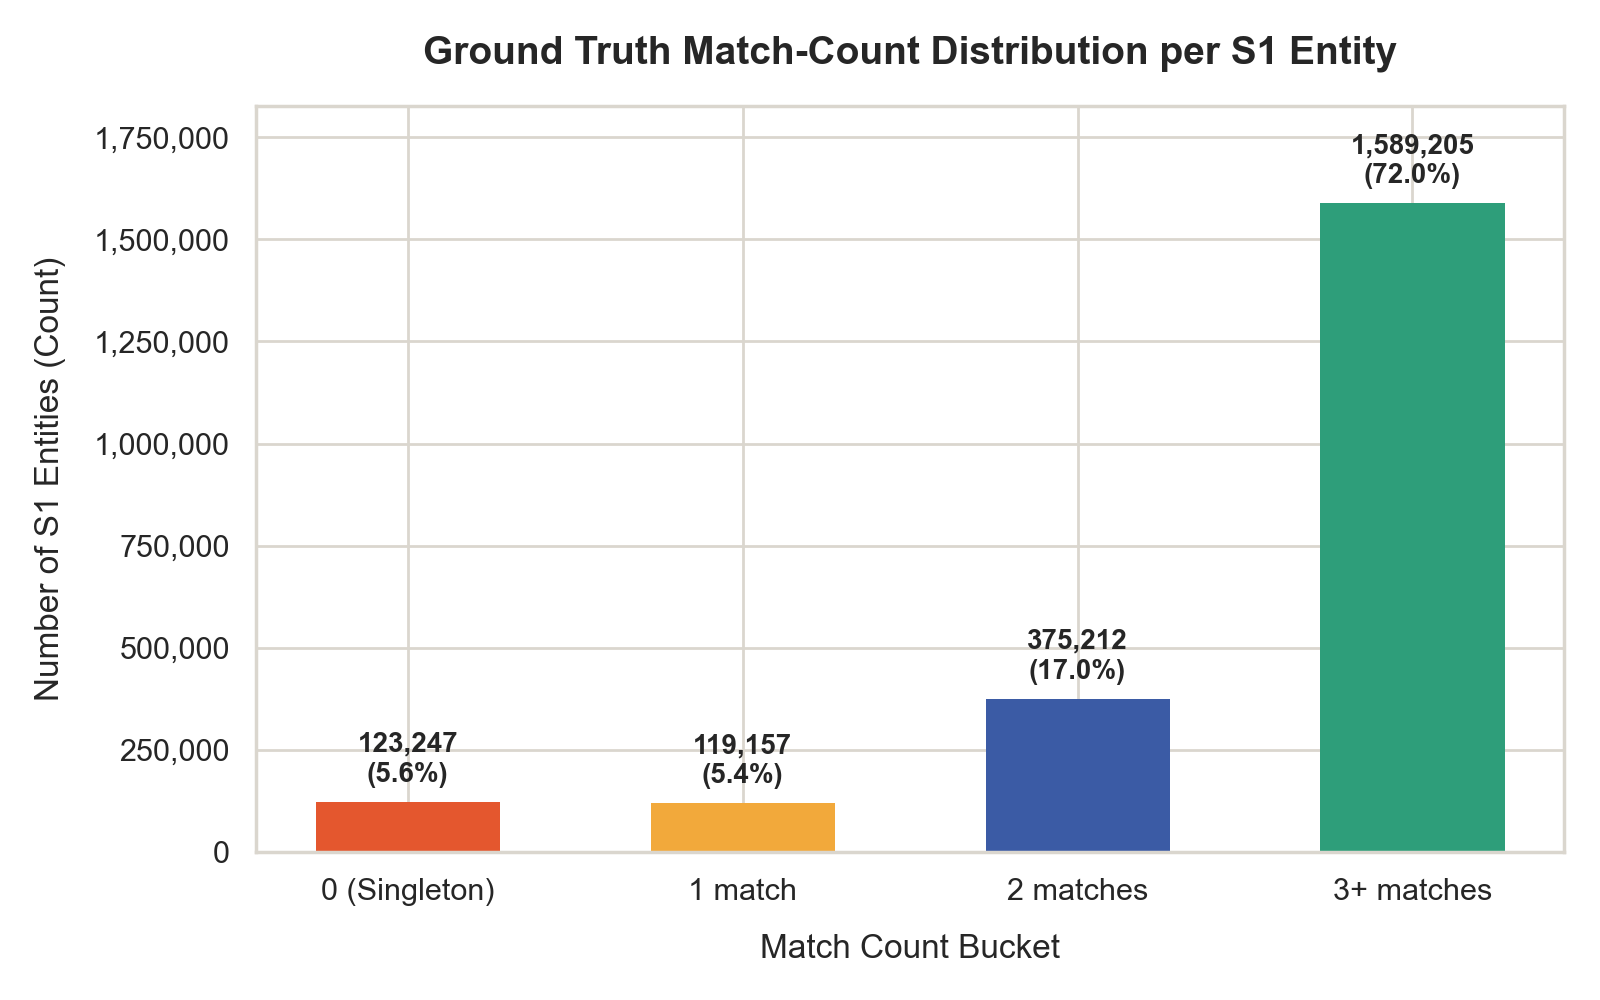

In [1]:
gt = train_dfs["train_ground_truth"]

def parse_match_count(val):
    if pd.isna(val) or not str(val).strip():
        return 0
    return len([x for x in str(val).split(",") if x.strip()])

gt["match_count"] = gt["matched_entity_ids"].apply(parse_match_count)

def to_bucket(c):
    if c == 0:
        return "0 (Singleton)"
    elif c == 1:
        return "1 match"
    elif c == 2:
        return "2 matches"
    else:
        return "3+ matches"

gt["match_bucket"] = gt["match_count"].apply(to_bucket)

bucket_order = ["0 (Singleton)", "1 match", "2 matches", "3+ matches"]
bucket_counts = gt["match_bucket"].value_counts().reindex(bucket_order)
bucket_pcts = gt["match_bucket"].value_counts(normalize=True).reindex(bucket_order) * 100

summary_df = pd.DataFrame({
    "Match Bucket": bucket_order,
    "Count": bucket_counts.values,
    "Percentage (%)": bucket_pcts.values.round(2),
})
print("Match-Count Distribution Summary:")
print(summary_df.to_string(index=False))

singleton_rate = bucket_pcts["0 (Singleton)"]
print(f"\nSingleton rate in train ground truth: {singleton_rate:.2f}%")

# Plotting using semantic colors from design.md
colors = [
    PALETTE["coral_red"],   # 0 (Singleton) - Red
    PALETTE["amber"],       # 1 match - Amber
    PALETTE["slate_blue"],  # 2 matches - Slate blue
    PALETTE["teal_green"],  # 3+ matches - Teal green
]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(summary_df["Match Bucket"], summary_df["Count"], color=colors, width=0.55, edgecolor="none")

ax.set_title("Ground Truth Match-Count Distribution per S1 Entity", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Match Count Bucket", fontsize=12, labelpad=10)
ax.set_ylabel("Number of S1 Entities (Count)", fontsize=12, labelpad=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))

# Add data labels
for bar, pct in zip(bars, summary_df["Percentage (%)"]):
    height = bar.get_height()
    ax.annotate(f"{height:,}\n({pct:.1f}%)",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points",
                ha="center", va="bottom", fontsize=10, fontweight="semibold")

plt.ylim(0, max(summary_df["Count"]) * 1.15)
plt.tight_layout()
os.makedirs("notebooks", exist_ok=True)
plot_path = "notebooks/match_count_distribution.png"
plt.savefig(plot_path, dpi=200)
plt.show()
print(f"Chart saved to {plot_path}")

## 4. Real Matched Pairs Inspection (Noise Pattern Table)
Sample 40 real matched pairs across S1 -> S2 / S3 (side-by-side name and address) to inspect actual noise patterns:
- Legal suffix variants (`Ltd` vs `Limited`, `Pvt` vs `Private`, `Corp` vs `Corporation`, `Inc` vs `Incorporated`)
- Address abbreviations (`Rd` vs `Road`, `St` vs `Street`, `Cir` vs `Circle`, `Apt` vs `Apartment`, `Flr` vs `Floor`)
- Punctuation & casing (`&` vs `and`, uppercase vs lowercase, hyphenation)
- Typos & spelling corruptions
- Missing PIN codes, landmarks (`Near SBI ATM`), city omissions

In [1]:
# Sample 40 real matches across US and India, S2 and S3
gt_with_matches = gt[gt["match_count"] > 0].copy()

sample_gt = gt_with_matches.sample(35, random_state=42)
s1_df = train_dfs["train_source1"]
s1_lookup = s1_df.set_index("entity_id").to_dict("index")

needed_s2 = set()
needed_s3 = set()
sample_pairs = []

for _, row in sample_gt.iterrows():
    s1_id = row["source1_entity_id"]
    mids = [m.strip() for m in str(row["matched_entity_ids"]).split(",") if m]
    for mid in mids:
        sample_pairs.append((s1_id, mid))
        if mid.startswith("S2-"):
            needed_s2.add(mid)
        elif mid.startswith("S3-"):
            needed_s3.add(mid)
        if len(sample_pairs) >= 40:
            break
    if len(sample_pairs) >= 40:
        break

# Lookup records from S2 and S3 efficiently
s2_lookup = {}
with open("dataset/train/train_source2.tsv", "r", encoding="utf-8") as f:
    header = f.readline().strip().split("\t")
    for line in f:
        eid = line.split("\t", 1)[0]
        if eid in needed_s2:
            s2_lookup[eid] = dict(zip(header, line.strip().split("\t")))
            if len(s2_lookup) == len(needed_s2):
                break

s3_lookup = {}
with open("dataset/train/train_source3.tsv", "r", encoding="utf-8") as f:
    header = f.readline().strip().split("\t")
    for line in f:
        eid = line.split("\t", 1)[0]
        if eid in needed_s3:
            s3_lookup[eid] = dict(zip(header, line.strip().split("\t")))
            if len(s3_lookup) == len(needed_s3):
                break

# Print 40 pairs side by side
print("="*105)
print(f"{'#':<3} | {'SOURCE 1 (Reference)':<48} | {'MATCHED RECORD (S2 / S3)':<48}")
print("="*105)

for idx, (s1_id, mid) in enumerate(sample_pairs, start=1):
    s1_rec = s1_lookup.get(s1_id, {})
    m_rec = s2_lookup.get(mid) if mid.startswith("S2-") else s3_lookup.get(mid)
    if not m_rec:
        continue
    
    c = s1_rec.get("country", "")
    print(f"\n[Pair {idx:02d}]  Country: {c} | S1 ID: {s1_id} <---> Match ID: {mid}")
    print("-" * 105)
    print(f"  NAME:    {s1_rec.get('business_name', ''):<45} | {m_rec.get('business_name', ''):<45}")
    print(f"  ADDRESS: {s1_rec.get('business_address', ''):<45} | {m_rec.get('business_address', ''):<45}")

print("\n" + "="*105)
print("Hand-crafted noise inspection complete. 40 real matched pairs displayed.")

#   | SOURCE 1 (Reference)                             | MATCHED RECORD (S2 / S3)                        

[Pair 01]  Country: US | S1 ID: S1-777210964 <---> Match ID: S2-12029274
---------------------------------------------------------------------------------------------------------
  NAME:    Davis Family Office                           | Davis Family Offie                           
  ADDRESS: 88 Olive Circle, Lebanon, TN                  | 88 OLIVE CIR, LEBANON, TN                    

[Pair 02]  Country: US | S1 ID: S1-777210964 <---> Match ID: S2-407524980
---------------------------------------------------------------------------------------------------------
  NAME:    Davis Family Office                           | DAVIS FAMILY OFFICE                          
  ADDRESS: 88 Olive Circle, Lebanon, TN                  | OLIVE CIR, LEBANON, TN                       

[Pair 03]  Country: US | S1 ID: S1-777210964 <---> Match ID: S3-970714334
--------------------------------------

## 5. Stratified Train / Validation Split
Create a stratified split on S1 entities partitioned by match-count bucket (`0`, `1`, `2`, `3+`).
- Target: 20% validation split (~441k S1 entities).
- Output: `dataset/val_split_ids.txt`.
- **Immutable Rule:** NEVER regenerate this file once it exists. If it exists, load it directly.

In [1]:
val_split_file = "dataset/val_split_ids.txt"

if os.path.exists(val_split_file):
    print(f"[FOUND EXISTING SPLIT] Loading {val_split_file}...")
    with open(val_split_file, "r", encoding="utf-8") as f:
        val_ids = [line.strip() for line in f if line.strip()]
    val_id_set = set(val_ids)
    print(f"Loaded {len(val_ids):,} validation S1 IDs from {val_split_file}.")
    is_new = False
else:
    print(f"[CREATING NEW SPLIT] Stratifying by match_bucket (80/20 split)...")
    train_ids, val_ids = train_test_split(
        gt["source1_entity_id"],
        test_size=0.20,
        stratify=gt["match_bucket"],
        random_state=42
    )
    val_id_set = set(val_ids)
    
    # Save to dataset/val_split_ids.txt
    os.makedirs("dataset", exist_ok=True)
    with open(val_split_file, "w", encoding="utf-8") as f:
        for vid in val_ids:
            f.write(f"{vid}\n")
    print(f"Saved {len(val_ids):,} validation S1 IDs to {val_split_file} (COMMITTED & LOCKED).")
    is_new = True

# Verify Stratification Distribution
gt["is_val"] = gt["source1_entity_id"].isin(val_id_set)
train_dist = gt[~gt["is_val"]]["match_bucket"].value_counts(normalize=True) * 100
val_dist = gt[gt["is_val"]]["match_bucket"].value_counts(normalize=True) * 100

split_comparison = pd.DataFrame({
    "Match Bucket": bucket_order,
    "Overall Train (%)": bucket_pcts.values.round(2),
    "Train Split (%)": train_dist.reindex(bucket_order).values.round(2),
    "Val Split (%)": val_dist.reindex(bucket_order).values.round(2),
    "Val Count": gt[gt["is_val"]]["match_bucket"].value_counts().reindex(bucket_order).values,
})

print("\n" + "="*60)
print("TRAIN / VALIDATION STRATIFICATION VERIFICATION:")
print(split_comparison.to_string(index=False))
print("="*60)
print(f"\nTotal Validation S1 Entities: {len(val_id_set):,}")
print(f"Total Train S1 Entities:      {len(gt) - len(val_id_set):,}")
print(f"Lock check: {val_split_file} exists and will NOT be regenerated in future runs.")

[CREATING NEW SPLIT] Stratifying by match_bucket (80/20 split)...
Saved 441,365 validation S1 IDs to dataset/val_split_ids.txt (COMMITTED & LOCKED).

TRAIN / VALIDATION STRATIFICATION VERIFICATION:
 Match Bucket  Overall Train (%)  Train Split (%)  Val Split (%)  Val Count
0 (Singleton)               5.58             5.58           5.58      24649
      1 match               5.40             5.40           5.40      23831
    2 matches              17.00            17.00          17.00      75043
   3+ matches              72.01            72.01          72.01     317842

Total Validation S1 Entities: 441,365
Total Train S1 Entities:      1,765,456
Lock check: dataset/val_split_ids.txt exists and will NOT be regenerated in future runs.
